In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Skill_Test_Data.csv')
df.head()

,order_no,customer_name,city,pincode,product_purchased,qty_purchased,marketing_channel
0,ORD00001,Reyansh,Mumbai,400001,baby shampoo,4,whatsapp
1,ORD00002,Aarav,Jaipur,302002,baby shampoo,4,instagram
2,ORD00003,Advait,Jaipur,302002,baby laundry,1,whatsapp
3,ORD00004,Tara,Hyderabad,500001,baby shampoo,4,facebook
4,ORD00005,Yash,Bengaluru,560002,baby handwash,2,facebook


In [4]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
order_no             0
customer_name        0
city                 0
pincode              0
product_purchased    0
qty_purchased        0
marketing_channel    0
dtype: int64


In [11]:
print(df['qty_purchased'].describe())

count    500.000000
mean       2.456000
std        1.103857
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: qty_purchased, dtype: float64


In [17]:
print(f"""
    customers: {df['customer_name'].nunique()} 
    customers_list: {sorted(df['customer_name'].unique().tolist())}

    cities_count: {df['city'].nunique()}
    cities_list: {sorted(df['city'].unique().tolist())}
    
    products_count: {df['product_purchased'].nunique()}
    products_list: {sorted(df['product_purchased'].unique().tolist())}

    channels_count: {df['marketing_channel'].nunique()}
    channels_list: {sorted(df['marketing_channel'].unique().tolist())}
""")


    customers: 18 
    customers_list: ['Aarav', 'Aditi', 'Advait', 'Anaya', 'Arjun', 'Kabir', 'Karan', 'Kiara', 'Myra', 'Neha', 'Nisha', 'Pooja', 'Raghav', 'Reyansh', 'Simran', 'Tara', 'Vivaan', 'Yash']

    cities_count: 8
    cities_list: ['Ahmedabad', 'Bengaluru', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Kolkata', 'Mumbai']
    
    products_count: 4
    products_list: ['baby bodywash', 'baby handwash', 'baby laundry', 'baby shampoo']

    channels_count: 4
    channels_list: ['facebook', 'google', 'instagram', 'whatsapp']



## Total Quantity Sold by Product

In [36]:
product_perf = (
    df.groupby('product_purchased')['qty_purchased']
      .agg(n_orders='count', total_qty='sum', avg_qty_per_order='mean')
      .sort_values('total_qty', ascending=False)
)

print("\nProduct performance")
print(product_perf)


Product performance
                   n_orders  total_qty  avg_qty_per_order
product_purchased                                        
baby laundry            209        503           2.406699
baby shampoo            178        438           2.460674
baby bodywash            65        174           2.676923
baby handwash            48        113           2.354167


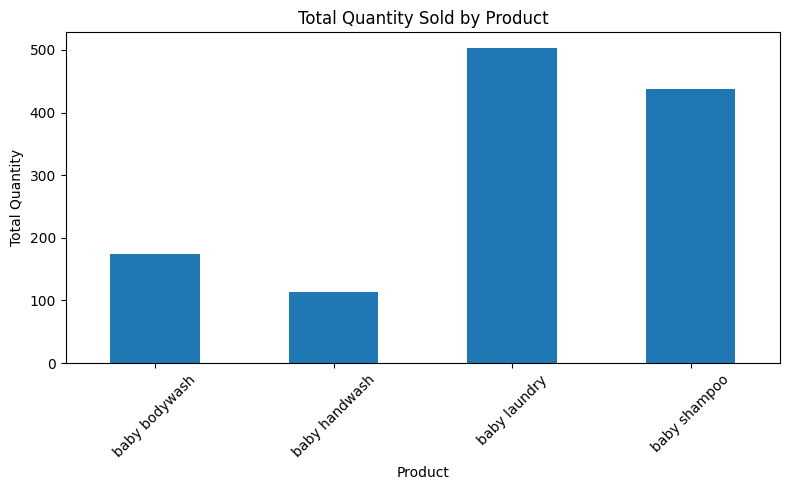

In [29]:
product_qty = df.groupby('product_purchased')['qty_purchased'].sum()

plt.figure(figsize=(8,5))
product_qty.plot(kind='bar')
plt.title("Total Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Total Quantity Sold by Marketing Channel

In [42]:
channel_perf = (
    df.groupby('marketing_channel')['qty_purchased']
      .agg(n_orders='count', total_qty='sum', avg_qty_per_order='mean')
      .sort_values('total_qty', ascending=False)
)

print("\nChannel performance")
print(channel_perf)



Channel performance
                   n_orders  total_qty  avg_qty_per_order
marketing_channel                                        
whatsapp                131        334           2.549618
facebook                131        321           2.450382
instagram               125        303           2.424000
google                  113        270           2.389381


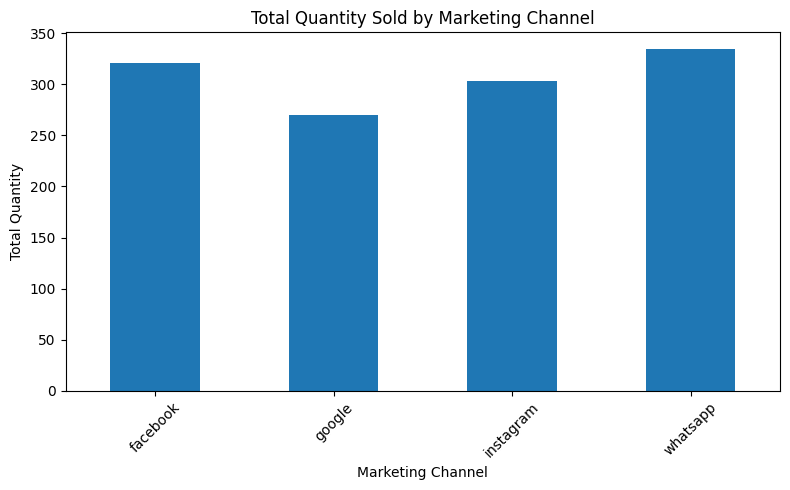

In [30]:
channel_qty = df.groupby('marketing_channel')['qty_purchased'].sum()

plt.figure(figsize=(8,5))
channel_qty.plot(kind='bar')
plt.title("Total Quantity Sold by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Average Quantity per City

In [38]:
city_perf = (
    df.groupby('city')['qty_purchased']
      .agg(n_orders='count', total_qty='sum', avg_qty_per_order='mean')
      .sort_values('total_qty', ascending=False)
)

print("\nCity performance")
print(city_perf)


City performance
           n_orders  total_qty  avg_qty_per_order
city                                             
Kolkata          74        175           2.364865
Delhi            69        174           2.521739
Ahmedabad        70        165           2.357143
Mumbai           68        161           2.367647
Jaipur           59        160           2.711864
Hyderabad        60        139           2.316667
Chennai          50        135           2.700000
Bengaluru        50        119           2.380000


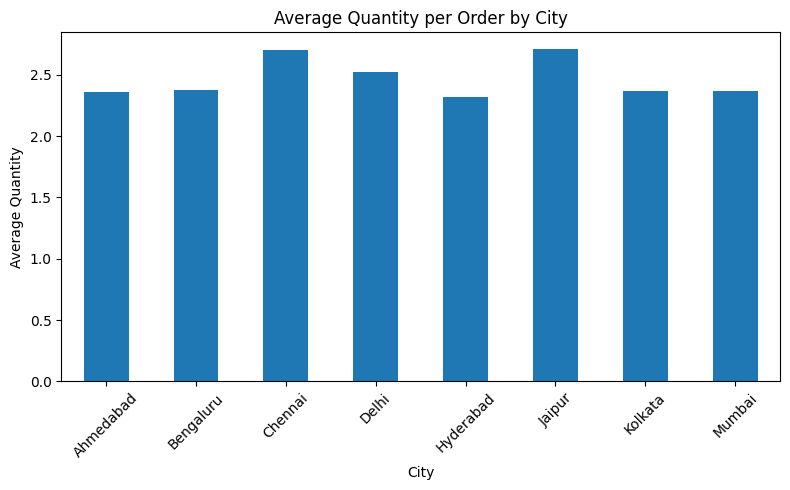

In [31]:
city_avg = df.groupby('city')['qty_purchased'].mean()

plt.figure(figsize=(8,5))
city_avg.plot(kind='bar')
plt.title("Average Quantity per Order by City")
plt.xlabel("City")
plt.ylabel("Average Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## City × Channel Heatmap

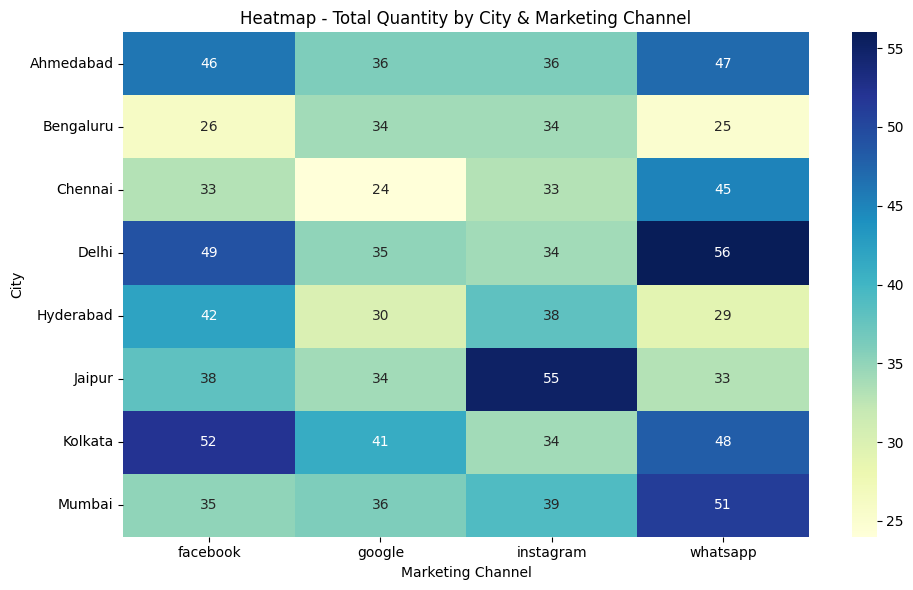

In [32]:
city_channel = df.pivot_table(
    index='city',
    columns='marketing_channel',
    values='qty_purchased',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(city_channel, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap - Total Quantity by City & Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("City")
plt.tight_layout()
plt.show()

## City × Product Heatmap

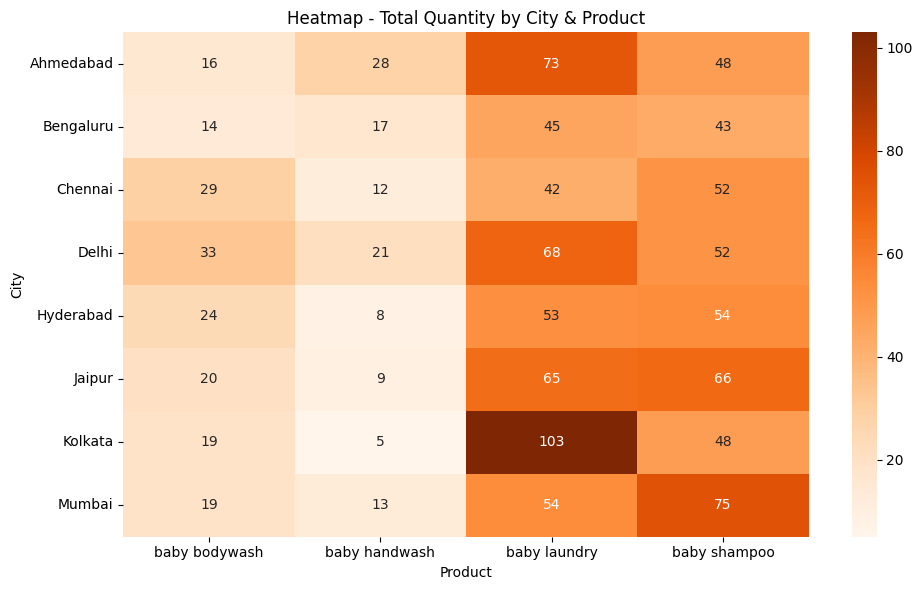

In [33]:
city_product = df.pivot_table(
    index='city',
    columns='product_purchased',
    values='qty_purchased',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(city_product, annot=True, fmt=".0f", cmap="Oranges")
plt.title("Heatmap - Total Quantity by City & Product")
plt.xlabel("Product")
plt.ylabel("City")
plt.tight_layout()
plt.show()

## City and Channel Performance

In [44]:
city_channel = (
    df.groupby(['city', 'marketing_channel'])['qty_purchased']
      .agg(n_orders='count', total_qty='sum', avg_qty_per_order='mean')
      .reset_index()
      .sort_values(['city', 'total_qty'], ascending=[True, False])
)

print("\nCity x Channel performance")
print(city_channel.head(20))


City x Channel performance
         city marketing_channel  n_orders  total_qty  avg_qty_per_order
3   Ahmedabad          whatsapp        20         47           2.350000
0   Ahmedabad          facebook        18         46           2.555556
1   Ahmedabad            google        18         36           2.000000
2   Ahmedabad         instagram        14         36           2.571429
5   Bengaluru            google        14         34           2.428571
6   Bengaluru         instagram        13         34           2.615385
4   Bengaluru          facebook        13         26           2.000000
7   Bengaluru          whatsapp        10         25           2.500000
11    Chennai          whatsapp        15         45           3.000000
8     Chennai          facebook        13         33           2.538462
10    Chennai         instagram        12         33           2.750000
9     Chennai            google        10         24           2.400000
15      Delhi          whatsapp     

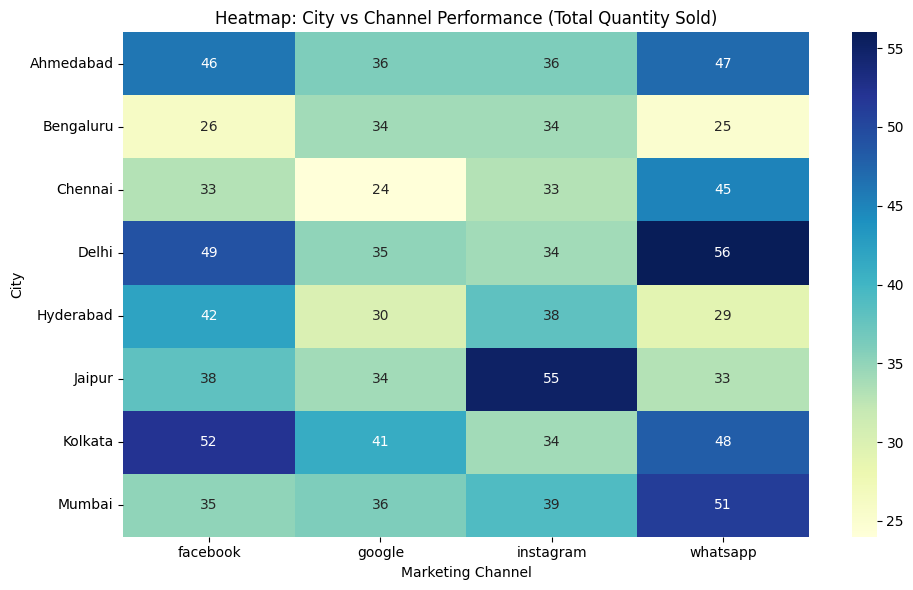

In [45]:
city_channel = df.pivot_table(
    index='city',
    columns='marketing_channel',
    values='qty_purchased',
    aggfunc='sum'
)

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(city_channel, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap: City vs Channel Performance (Total Quantity Sold)")
plt.xlabel("Marketing Channel")
plt.ylabel("City")
plt.tight_layout()
plt.show()

## Top 10 Customers

In [43]:
cust_perf = (
    df.groupby('customer_name')['qty_purchased']
      .agg(n_orders='count', total_qty='sum', avg_qty_per_order='mean')
      .sort_values('total_qty', ascending=False)
)

print("\nTop 10 customers by total quantity")
print(cust_perf.head(10))


Top 10 customers by total quantity
               n_orders  total_qty  avg_qty_per_order
customer_name                                        
Advait               72        177           2.458333
Vivaan               56        133           2.375000
Tara                 55        131           2.381818
Neha                 32         83           2.593750
Reyansh              29         82           2.827586
Kabir                32         81           2.531250
Karan                31         76           2.451613
Anaya                23         58           2.521739
Pooja                22         56           2.545455
Myra                 25         53           2.120000


## Pincode Performance

In [46]:
pin_perf = (
    df.groupby('pincode')['qty_purchased'].agg(n_orders='count', total_qty='sum', avg_qty_per_order='mean')
      .sort_values('avg_qty_per_order', ascending=False)
)

print("\nPincode performance (sorted by avg qty per order)")
print(pin_perf.head(10))


Pincode performance (sorted by avg qty per order)
         n_orders  total_qty  avg_qty_per_order
pincode                                        
600002         13         40           3.076923
400001         21         64           3.047619
302002         19         56           2.947368
500001         19         52           2.736842
110001         22         60           2.727273
302001         21         56           2.666667
380002         17         45           2.647059
560003         22         58           2.636364
600003         18         47           2.611111
110003         23         59           2.565217
